# Image → Top-k Similar Reference Views

Standalone experiment notebook for `image_view_matcher.py`'s CLIP **image** embeddings — the image-side counterpart to `text_similarity_lookup.ipynb`. Independent of `session`, the camera, or any iteration loop.

Point `query_image_path` at any screenshot (a live render, a saved `output/screenshots/step_*.png`, or one of the reference images themselves) and see which reference views (`reference_views/*.png`) it's closest to, by cosine similarity on normalized CLIP image embeddings.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from IPython.display import Image, display
from camera_reasoning.image_view_matcher import ImageViewMatcher, save_contact_sheet

## Build the index (once)

Loads from the cache if present (`reference_embeddings.pkl`), otherwise encodes every image in `reference_views/` from scratch and writes the cache.

In [2]:
image_matcher = ImageViewMatcher(
    reference_dir="../reference_views",
    cache_path="../reference_embeddings.pkl",
)
image_matcher.build_index()

[image_view_matcher] Loaded 6 cached reference embeddings from ../reference_embeddings.pkl


## Look up any image

Edit `query_image_path` below and re-run.

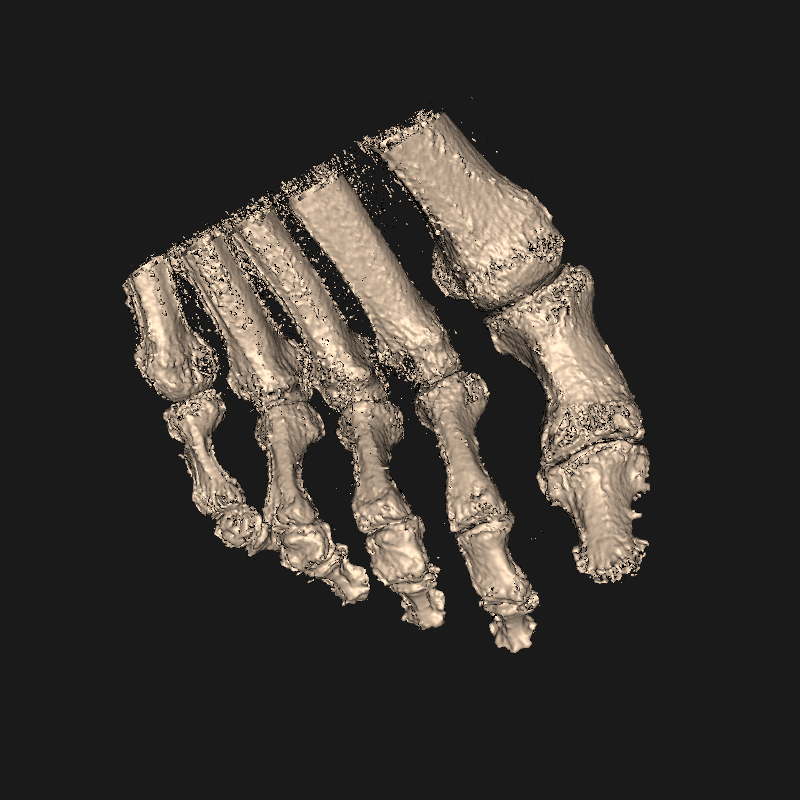

/Users/chulu/Documents/llm-vis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


[image_view_matcher] Loading 'openai/clip-vit-base-patch32' on cpu...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Best view: Distal
Confidence margin: 0.030667

Top 5 individual matches:
  1. Distal               similarity=0.7364
  2. Lateral              similarity=0.7057
  3. Plantar              similarity=0.7048
  4. Proximal             similarity=0.7028
  5. Dorsal               similarity=0.7019

Aggregated view scores:
  Distal               max=0.7364  mean=0.7364  n=1
  Lateral              max=0.7057  mean=0.7057  n=1
  Plantar              max=0.7048  mean=0.7048  n=1
  Proximal             max=0.7028  mean=0.7028  n=1
  Dorsal               max=0.7019  mean=0.7019  n=1
  Medial               max=0.6835  mean=0.6835  n=1


In [3]:
def topk_for_image(query_image_path: str, top_k: int = 5):
    result = image_matcher.match(query_image_path, top_k=top_k)

    ambiguous_note = "  (AMBIGUOUS)" if result["is_ambiguous"] else ""
    print(f"Best view: {result['best_view']}")
    print(f"Confidence margin: {result['confidence_margin']}{ambiguous_note}\n")

    print(f"Top {len(result['top_matches'])} individual matches:")
    for m in result["top_matches"]:
        print(f"  {m['rank']}. {m['view_label']:<20s} similarity={m['similarity']:.4f}")

    print("\nAggregated view scores:")
    for v in result["view_scores"]:
        print(
            f"  {v['view_label']:<20s} max={v['max_similarity']:.4f}  "
            f"mean={v['mean_similarity']:.4f}  n={v['num_references']}"
        )
    return result

query_image_path = "../output/screenshots/latest.png"
display(Image(query_image_path))
result = topk_for_image(query_image_path, top_k=5)

## Visual contact sheet

Saves the query image next to its top-k matches, labeled with rank/view/similarity — useful for eyeballing whether the matcher picked a sensible view.

In [ ]:
save_contact_sheet(query_image_path, result["top_matches"], "../output/image_similarity_contact_sheet.png")
display(Image("../output/image_similarity_contact_sheet.png"))